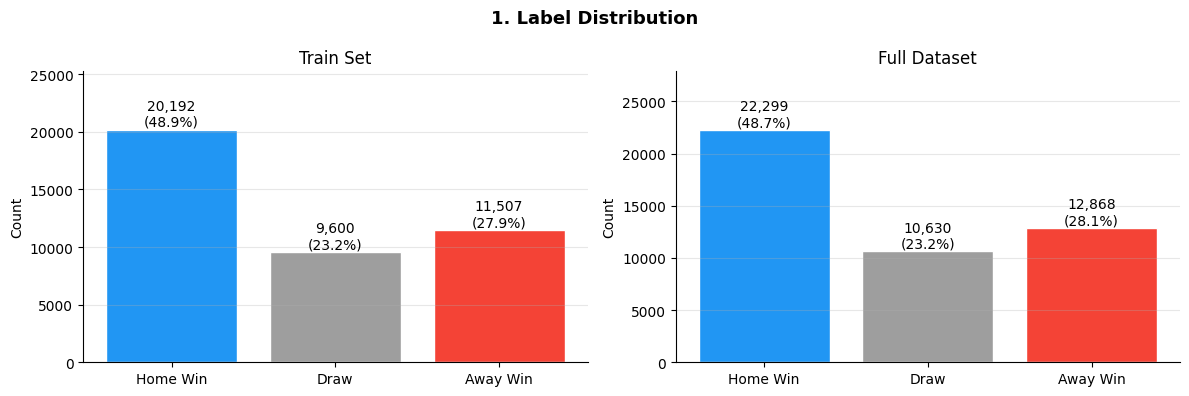

Train: 41,299경기  |  Test: 4,498경기  |  전체: 45,797경기

=== Train 레이블 분포 ===
  Home Win  : 20,192경기 (48.9%)
  Draw      : 9,600경기 (23.2%)
  Away Win  : 11,507경기 (27.9%)


In [1]:
# ============================================================
# EDA 1. 레이블 분포 (Label Distribution)
# ============================================================
# 목적: H(홈승=2) / D(무승부=1) / A(원정승=0) 클래스 불균형 확인
#       무승부가 구조적으로 적으면 모델이 무승부를 잘 못 맞추는 원인이 됨
#       → 이후 class_weight 보정 여부 결정에 활용
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SAVE_PATH = "/content/drive/MyDrive/[미래융합교육원] 1팀 공유사항/1차 머신러닝 프로젝트/@프로젝트 자료/03. 프로젝트 자료/data/preprocessed"

X_train = pd.read_csv(f"{SAVE_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{SAVE_PATH}/X_test.csv")
y_train = pd.read_csv(f"{SAVE_PATH}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{SAVE_PATH}/y_test.csv").squeeze()

X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)

LABEL_MAP   = {2: "Home Win", 1: "Draw", 0: "Away Win"}
COLOR_MAP   = {2: "#2196F3", 1: "#9E9E9E", 0: "#F44336"}
LABEL_ORDER = [2, 1, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("1. Label Distribution", fontsize=13, fontweight="bold")

for ax, (y, title) in zip(axes, [(y_train, "Train Set"), (y_all, "Full Dataset")]):
    counts = y.value_counts().reindex(LABEL_ORDER)
    bars = ax.bar(
        [LABEL_MAP[l] for l in LABEL_ORDER],
        counts.values,
        color=[COLOR_MAP[l] for l in LABEL_ORDER],
        edgecolor="white"
    )
    # 각 막대 위에 수치 + 비율 표시
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f"{cnt:,}\n({cnt/len(y)*100:.1f}%)",
                ha="center", va="bottom", fontsize=10)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.set_ylim(0, counts.max() * 1.25)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 수치 요약 출력
print(f"Train: {len(X_train):,}경기  |  Test: {len(X_test):,}경기  |  전체: {len(X_all):,}경기")
print()
print("=== Train 레이블 분포 ===")
for lbl in LABEL_ORDER:
    cnt = (y_train == lbl).sum()
    print(f"  {LABEL_MAP[lbl]:10s}: {cnt:,}경기 ({cnt/len(y_train)*100:.1f}%)")

## EDA 1. 레이블 분포 해석

**결과: 홈승 48.9% / 무승부 23.2% / 원정승 27.9%**

### ① 홈 어드밴티지 실재
홈승이 원정승보다 21%p 높음.
중립경기가 섞여있음에도 홈 어드밴티지가 데이터에 강하게 반영됨.

### ② 무승부 클래스 불균형
Draw가 23.2%로 가장 적음.
모델이 무승부를 포기하고 홈승/원정승에 집중하는 방향으로 학습될 가능성 있음.
→ 이후 모델 단계에서 클래스 가중치 보정 고려 필요

### ③ Train/Test 분포 일치
41,299 vs 4,498 (약 90:10 분할)
Full Dataset 기준 48.7% / 23.2% / 28.1%로 Train과 거의 동일
→ 시간 기반 분할임에도 분포 쏠림 없이 잘 나뉨

=== 대회 유형별 경기 수 (Train) ===
  World Cup         : 831경기  |  홈승 45.5%  무 22.3%  원정승 32.3%
  WC Qualifier      : 5,185경기  |  홈승 47.1%  무 23.8%  원정승 29.1%
  Continental       : 7,472경기  |  홈승 51.2%  무 21.3%  원정승 27.5%
  Friendly          : 15,750경기  |  홈승 47.0%  무 25.6%  원정승 27.5%


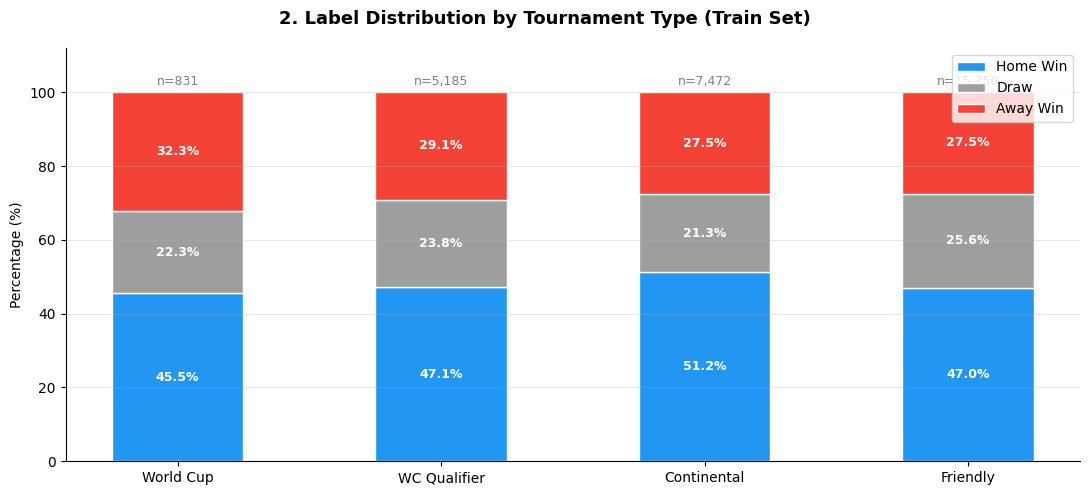

In [2]:
# ============================================================
# EDA 2. 대회 유형별 레이블 분포
# ============================================================
# 목적: WC / WC예선 / 대륙대회 / 친선 등 대회 유형에 따라
#       승/무/패 비율이 달라지는지 확인
#       → w_train(대회 가중치)이 의미 있는 피처인지 시각적 검증
#       → WC 경기는 중립경기 비중이 높아 홈승 비율이 낮을 것으로 예상
#
# w_train 가중치 기준:
#   1.0  = World Cup 본선
#   0.85 = WC 예선
#   0.7  = 대륙 대회 (AFCON, Copa America 등)
#   0.5  = 대륙 예선
#   0.3  = 친선경기
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SAVE_PATH = "/content/drive/MyDrive/[미래융합교육원] 1팀 공유사항/1차 머신러닝 프로젝트/@프로젝트 자료/03. 프로젝트 자료/data/preprocessed"

X_train = pd.read_csv(f"{SAVE_PATH}/X_train.csv")
y_train = pd.read_csv(f"{SAVE_PATH}/y_train.csv").squeeze()
w_train = pd.read_csv(f"{SAVE_PATH}/w_train.csv").squeeze()

LABEL_MAP   = {2: "Home Win", 1: "Draw", 0: "Away Win"}
COLOR_MAP   = {2: "#2196F3", 1: "#9E9E9E", 0: "#F44336"}
LABEL_ORDER = [2, 1, 0]

# w_train 가중치 값 → 대회 유형 이름 매핑
WEIGHT_LABELS = {
    1.0:  "World Cup",
    0.85: "WC Qualifier",
    0.7:  "Continental",
    0.5:  "Cont. Qualifier",
    0.3:  "Friendly",
}

df = X_train.copy()
df["label"]      = y_train.values
df["weight"]     = w_train.values
df["tournament"] = df["weight"].map(WEIGHT_LABELS).fillna("Other")

# 대회 유형별 경기 수 확인
print("=== 대회 유형별 경기 수 (Train) ===")
order = ["World Cup", "WC Qualifier", "Continental", "Cont. Qualifier", "Friendly"]
order = [o for o in order if o in df["tournament"].unique()]
for t in order:
    sub = df[df["tournament"] == t]
    hw  = (sub["label"] == 2).mean() * 100
    d   = (sub["label"] == 1).mean() * 100
    aw  = (sub["label"] == 0).mean() * 100
    print(f"  {t:18s}: {len(sub):,}경기  |  홈승 {hw:.1f}%  무 {d:.1f}%  원정승 {aw:.1f}%")

# 누적 막대 차트
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("2. Label Distribution by Tournament Type (Train Set)",
             fontsize=13, fontweight="bold")

bottom = np.zeros(len(order))
for label in LABEL_ORDER:
    vals = []
    for t in order:
        sub   = df[df["tournament"] == t]
        total = len(sub)
        cnt   = (sub["label"] == label).sum()
        vals.append(cnt / total * 100 if total > 0 else 0)
    bars = ax.bar(order, vals, bottom=bottom,
                  label=LABEL_MAP[label], color=COLOR_MAP[label],
                  width=0.5, edgecolor="white")
    # 각 구간 안에 비율 텍스트 표시 (5% 이상일 때만)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 5:
            ax.text(i, b + v/2, f"{v:.1f}%",
                    ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    bottom += np.array(vals)

# 각 막대 위에 경기 수 표시
for i, t in enumerate(order):
    n = len(df[df["tournament"] == t])
    ax.text(i, 102, f"n={n:,}", ha="center", fontsize=9, color="gray")

ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 112)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## EDA 2. 대회 유형별 레이블 분포 해석

**결과: 대회 중요도가 높을수록 원정승 비율 증가**

| 대회 유형 | 경기 수 | 홈승 | 무승부 | 원정승 |
|---|---|---|---|---|
| World Cup | 831 | 45.5% | 22.3% | **32.3%** |
| WC Qualifier | 5,185 | 47.1% | 23.8% | 29.1% |
| Continental | 7,472 | 51.2% | 21.3% | 27.5% |
| Friendly | 15,750 | 47.0% | 25.6% | 27.5% |

### ① WC에서 홈 어드밴티지 약화
World Cup 홈승 45.5%로 전체 평균(48.9%)보다 낮음.
→ WC는 중립 경기장 비중이 높아 홈 어드밴티지가 희석됨.
→ 2026 WC 예측 시 neutral=1 피처가 중요하게 작용할 것으로 예상.

### ② WC에서 원정승 비율 가장 높음 (32.3%)
강팀들이 원정(사실상 중립)에서도 실력으로 이기는 경향.
→ delta_elo 같은 전력 차이 피처가 WC에서 더 결정적일 가능성.

### ③ Continental에서 홈승 가장 높음 (51.2%)
대륙 대회는 자국/인근 개최가 많아 실질적 홈 어드밴티지 작용.

### ④ Friendly에서 무승부 가장 많음 (25.6%)
친선경기는 승부 부담이 없어 무승부로 끝나는 경향.
→ w_train에서 친선경기 가중치(0.3)를 낮게 준 것이 타당함을 확인.

### → 모델링 시사점
WC 경기(831경기)가 전체 Train의 2%에 불과 → 샘플 가중치(w_train) 없이는
WC 패턴을 제대로 학습하기 어려움. sample_weight 적용이 필수.

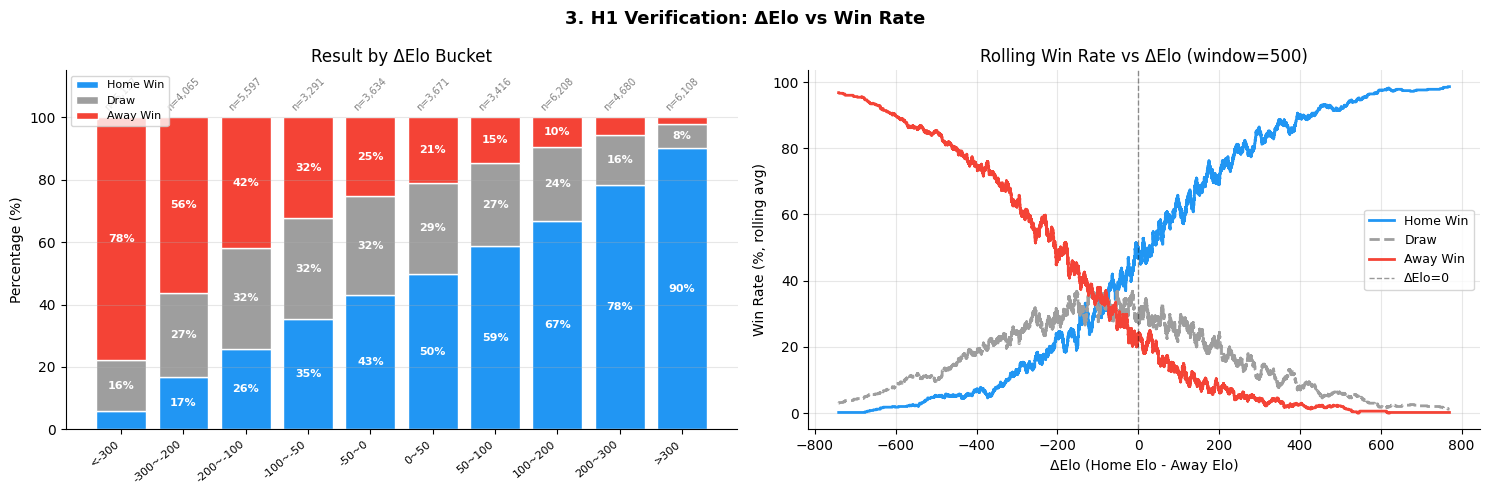

=== ΔElo 구간별 홈승률 ===
         <-300 (n=5,127): 홈승 5.9%  무 16.2%  원정승 77.8%
     -300~-200 (n=4,065): 홈승 16.8%  무 27.0%  원정승 56.2%
     -200~-100 (n=5,597): 홈승 25.8%  무 32.3%  원정승 41.9%
      -100~-50 (n=3,291): 홈승 35.2%  무 32.4%  원정승 32.4%
         -50~0 (n=3,634): 홈승 43.1%  무 31.6%  원정승 25.3%
          0~50 (n=3,671): 홈승 49.7%  무 29.2%  원정승 21.0%
        50~100 (n=3,416): 홈승 58.7%  무 26.6%  원정승 14.7%
       100~200 (n=6,208): 홈승 66.8%  무 23.6%  원정승 9.6%
       200~300 (n=4,680): 홈승 78.3%  무 16.0%  원정승 5.7%
          >300 (n=6,108): 홈승 90.0%  무 7.9%  원정승 2.1%


In [3]:
# ============================================================
# EDA 3. H1 검증: delta_elo vs 승률
# ============================================================
# 목적: "ΔElo가 가장 강력한 단일 예측 변수"라는 가설(H1) 시각적 검증
#       ΔElo = home_elo - away_elo
#       → ΔElo가 클수록 홈팀 승률이 단조증가하면 H1 지지
#
# 시각화 2가지:
#   왼쪽: ΔElo 구간(bin)별 승/무/패 비율 누적 막대
#   오른쪽: ΔElo 연속값 기준 롤링 승률 곡선
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SAVE_PATH = "/content/drive/MyDrive/[미래융합교육원] 1팀 공유사항/1차 머신러닝 프로젝트/@프로젝트 자료/03. 프로젝트 자료/data/preprocessed"

X_train = pd.read_csv(f"{SAVE_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{SAVE_PATH}/X_test.csv")
y_train = pd.read_csv(f"{SAVE_PATH}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{SAVE_PATH}/y_test.csv").squeeze()

X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)

LABEL_MAP   = {2: "Home Win", 1: "Draw", 0: "Away Win"}
COLOR_MAP   = {2: "#2196F3", 1: "#9E9E9E", 0: "#F44336"}
LABEL_ORDER = [2, 1, 0]

df = X_all.copy()
df["label"] = y_all.values

# ΔElo 구간 설정
bins       = [-np.inf, -300, -200, -100, -50, 0, 50, 100, 200, 300, np.inf]
bin_labels = ["<-300","-300~-200","-200~-100","-100~-50",
              "-50~0","0~50","50~100","100~200","200~300",">300"]
df["elo_bin"] = pd.cut(df["delta_elo"], bins=bins, labels=bin_labels)

# 구간별 비율 계산
bin_stats = []
for b in bin_labels:
    sub = df[df["elo_bin"] == b]
    if len(sub) == 0:
        continue
    bin_stats.append({
        "bin":      b,
        "n":        len(sub),
        "home_win": (sub["label"] == 2).mean() * 100,
        "draw":     (sub["label"] == 1).mean() * 100,
        "away_win": (sub["label"] == 0).mean() * 100,
    })
df_bin = pd.DataFrame(bin_stats)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("3. H1 Verification: ΔElo vs Win Rate", fontsize=13, fontweight="bold")

# --- 왼쪽: ΔElo 구간별 누적 막대 ---
ax = axes[0]
bottom = np.zeros(len(df_bin))
for label, col in [(2,"home_win"),(1,"draw"),(0,"away_win")]:
    bars = ax.bar(range(len(df_bin)), df_bin[col], bottom=bottom,
                  label=LABEL_MAP[label], color=COLOR_MAP[label], edgecolor="white")
    for i, (v, b) in enumerate(zip(df_bin[col], bottom)):
        if v >= 7:
            ax.text(i, b + v/2, f"{v:.0f}%",
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    bottom += df_bin[col].values

# 각 구간 경기 수 표시
for i, row in df_bin.iterrows():
    ax.text(i, 102, f"n={row['n']:,}", ha="center", fontsize=7, color="gray", rotation=45)

ax.set_xticks(range(len(df_bin)))
ax.set_xticklabels(df_bin["bin"], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Percentage (%)")
ax.set_title("Result by ΔElo Bucket")
ax.set_ylim(0, 115)
ax.legend(loc="upper left", fontsize=8)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

# --- 오른쪽: ΔElo 연속값 롤링 승률 ---
ax2 = axes[1]
df_sorted = df.sort_values("delta_elo").dropna(subset=["delta_elo"])
window = 500  # 500경기 이동평균

roll_win  = (df_sorted["label"] == 2).rolling(window, center=True).mean() * 100
roll_draw = (df_sorted["label"] == 1).rolling(window, center=True).mean() * 100
roll_away = (df_sorted["label"] == 0).rolling(window, center=True).mean() * 100

ax2.plot(df_sorted["delta_elo"], roll_win,  color=COLOR_MAP[2], label="Home Win", linewidth=2)
ax2.plot(df_sorted["delta_elo"], roll_draw, color=COLOR_MAP[1], label="Draw",     linewidth=2, linestyle="--")
ax2.plot(df_sorted["delta_elo"], roll_away, color=COLOR_MAP[0], label="Away Win", linewidth=2)
ax2.axvline(0, color="black", linestyle="--", alpha=0.4, linewidth=1, label="ΔElo=0")
ax2.set_xlabel("ΔElo (Home Elo - Away Elo)")
ax2.set_ylabel("Win Rate (%, rolling avg)")
ax2.set_title(f"Rolling Win Rate vs ΔElo (window={window})")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 수치 요약
print("=== ΔElo 구간별 홈승률 ===")
for _, row in df_bin.iterrows():
    print(f"  {row['bin']:>12s} (n={row['n']:>5,}): 홈승 {row['home_win']:.1f}%  무 {row['draw']:.1f}%  원정승 {row['away_win']:.1f}%")

## EDA 3. H1 검증: ΔElo vs 승률

**결론: H1 강력하게 지지됨**

| ΔElo 구간 | 홈승 | 무승부 | 원정승 |
|---|---|---|---|
| < -300 | 5.9% | 16.2% | **77.8%** |
| -100 ~ -50 | 35.2% | 32.4% | 32.4% |
| 0 ~ 50 | 49.7% | 29.2% | 21.0% |
| 100 ~ 200 | 66.8% | 23.6% | 9.6% |
| > 300 | **90.0%** | 7.9% | 2.1% |

### ① ΔElo와 홈승률의 단조증가 관계 확인
ΔElo < -300 구간: 홈승 5.9% → ΔElo > 300 구간: 홈승 90.0%
ΔElo가 증가할수록 홈승률이 예외 없이 단조증가
→ **H1(ΔElo가 가장 강력한 단일 예측 변수) 시각적으로 강하게 지지됨**

### ② 롤링 곡선에서 교차점 확인
ΔElo = 0 근방에서 홈승/원정승 곡선이 교차
→ 전력이 동등할 때 홈 어드밴티지로 인해 홈승이 약간 우세

### ③ 무승부는 중간 구간에서 최대
ΔElo -100 ~ 0 구간에서 무승부 32% 내외로 최고치
→ 두 팀 전력이 비슷할수록 무승부 확률 상승 (구조적 특성 재확인)

### ④ 극단 구간의 샘플 쏠림 주의
ΔElo > 300 (n=6,108), < -300 (n=5,127)으로 극단 구간 샘플이 많음
→ 약소국 간 경기가 다수 포함된 것으로 추정
→ 모델 학습 시 sample_weight로 WC 경기에 가중치를 더 주는 이유

### → 모델링 시사점
delta_elo는 단독으로도 강한 예측력을 가짐
베이스라인 모델(Logistic Regression + delta_elo 단일 변수)의
성능이 의미 있는 수준으로 나올 것으로 예상됨

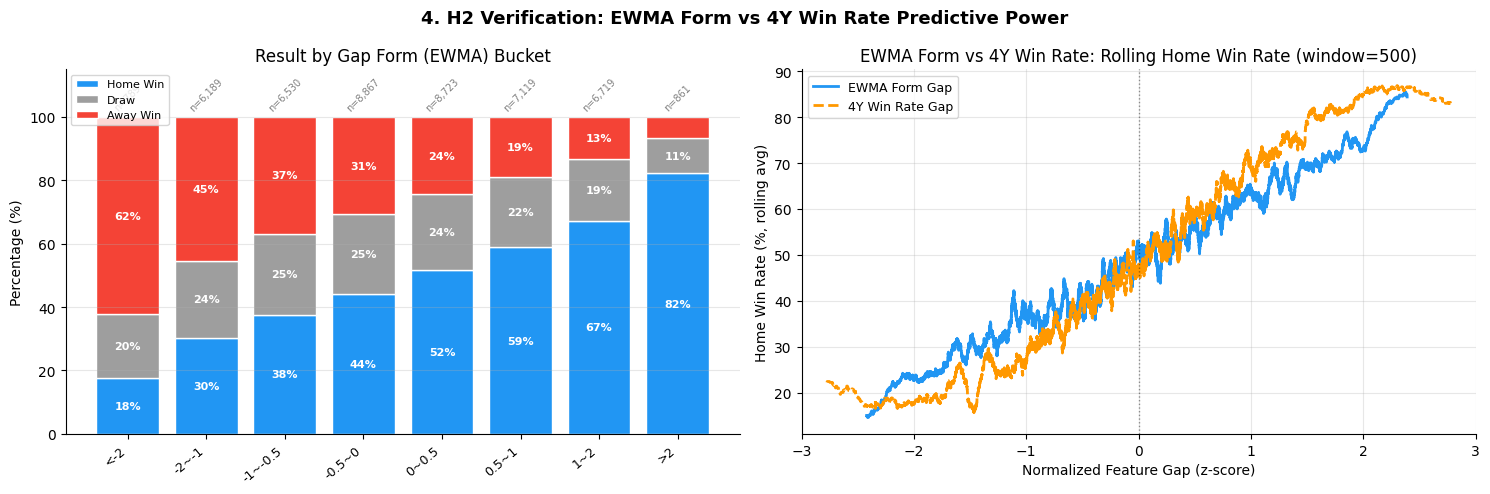

=== gap_form 구간별 홈승률 ===
         <-2 (n=  789): 홈승 17.7%  무 20.0%  원정승 62.2%
       -2~-1 (n=6,189): 홈승 30.2%  무 24.4%  원정승 45.4%
     -1~-0.5 (n=6,530): 홈승 37.6%  무 25.5%  원정승 36.9%
      -0.5~0 (n=8,867): 홈승 44.0%  무 25.2%  원정승 30.7%
       0~0.5 (n=8,723): 홈승 51.7%  무 23.8%  원정승 24.5%
       0.5~1 (n=7,119): 홈승 58.8%  무 22.3%  원정승 18.9%
         1~2 (n=6,719): 홈승 67.2%  무 19.3%  원정승 13.4%
          >2 (n=  861): 홈승 82.2%  무 11.1%  원정승 6.6%

=== label과의 상관계수 비교 ===
  gap_form                    : +0.2915
  gap_win_rate_4y             : +0.3632
  delta_elo                   : +0.5809


In [4]:
# ============================================================
# EDA 4. H2 검증: EWMA 폼 vs 4년 평균 예측력 비교
# ============================================================
# 목적: "최근 N경기 EWMA 폼이 전체 과거 평균보다 예측력이 높다"는
#       가설(H2) 시각적 검증
#
# 비교 대상:
#   gap_form        = home_form - away_form (EWMA 기반 최근 폼 차이)
#   gap_win_rate_4y = home_win_rate_4y - away_win_rate_4y (4년 평균 승률 차이)
#
# 두 피처가 증가할수록 홈승률이 얼마나 뚜렷하게 올라가는지 비교
# → 기울기가 더 가파른 쪽이 예측력이 높은 것
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SAVE_PATH = "/content/drive/MyDrive/[미래융합교육원] 1팀 공유사항/1차 머신러닝 프로젝트/@프로젝트 자료/03. 프로젝트 자료/data/preprocessed"

X_train = pd.read_csv(f"{SAVE_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{SAVE_PATH}/X_test.csv")
y_train = pd.read_csv(f"{SAVE_PATH}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{SAVE_PATH}/y_test.csv").squeeze()

X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)

COLOR_MAP   = {2: "#2196F3", 1: "#9E9E9E", 0: "#F44336"}
LABEL_MAP   = {2: "Home Win", 1: "Draw", 0: "Away Win"}
LABEL_ORDER = [2, 1, 0]

df = X_all.copy()
df["label"] = y_all.values

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("4. H2 Verification: EWMA Form vs 4Y Win Rate Predictive Power",
             fontsize=13, fontweight="bold")

# --- 왼쪽: gap_form 구간별 누적 막대 ---
ax = axes[0]
bins_form  = [-np.inf, -2, -1, -0.5, 0, 0.5, 1, 2, np.inf]
bin_labels = ["<-2", "-2~-1", "-1~-0.5", "-0.5~0", "0~0.5", "0.5~1", "1~2", ">2"]
df["form_bin"] = pd.cut(df["gap_form"], bins=bins_form, labels=bin_labels)

form_stats = []
for b in bin_labels:
    sub = df[df["form_bin"] == b]
    if len(sub) == 0:
        continue
    form_stats.append({
        "bin":      b,
        "n":        len(sub),
        "home_win": (sub["label"] == 2).mean() * 100,
        "draw":     (sub["label"] == 1).mean() * 100,
        "away_win": (sub["label"] == 0).mean() * 100,
    })
df_fb = pd.DataFrame(form_stats)

bottom = np.zeros(len(df_fb))
for label, col in [(2,"home_win"),(1,"draw"),(0,"away_win")]:
    ax.bar(range(len(df_fb)), df_fb[col], bottom=bottom,
           label=LABEL_MAP[label], color=COLOR_MAP[label], edgecolor="white")
    for i, (v, b) in enumerate(zip(df_fb[col], bottom)):
        if v >= 7:
            ax.text(i, b + v/2, f"{v:.0f}%",
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    bottom += df_fb[col].values

for i, row in df_fb.iterrows():
    ax.text(i, 102, f"n={row['n']:,}", ha="center", fontsize=7, color="gray", rotation=45)

ax.set_xticks(range(len(df_fb)))
ax.set_xticklabels(df_fb["bin"], rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Percentage (%)")
ax.set_title("Result by Gap Form (EWMA) Bucket")
ax.set_ylim(0, 115)
ax.legend(loc="upper left", fontsize=8)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

# --- 오른쪽: 롤링 홈승률 비교 (gap_form vs gap_win_rate_4y) ---
ax2 = axes[1]
window = 500

for feat, label_txt, color, ls in [
    ("gap_form",        "EWMA Form Gap",     "#2196F3", "-"),
    ("gap_win_rate_4y", "4Y Win Rate Gap",   "#FF9800", "--"),
]:
    df_s = df.sort_values(feat).dropna(subset=[feat])
    # 정규화: 각 피처를 -1~1 범위로 스케일해서 x축 비교 가능하게
    feat_norm = (df_s[feat] - df_s[feat].mean()) / df_s[feat].std()
    roll_hw   = (df_s["label"] == 2).rolling(window, center=True).mean() * 100
    ax2.plot(feat_norm, roll_hw, label=label_txt, color=color,
             linewidth=2, linestyle=ls)

ax2.axvline(0, color="black", linestyle=":", alpha=0.4, linewidth=1)
ax2.set_xlabel("Normalized Feature Gap (z-score)")
ax2.set_ylabel("Home Win Rate (%, rolling avg)")
ax2.set_title(f"EWMA Form vs 4Y Win Rate: Rolling Home Win Rate (window={window})")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.spines[["top","right"]].set_visible(False)
ax2.set_xlim(-3, 3)

plt.tight_layout()
plt.show()

# 수치 요약
print("=== gap_form 구간별 홈승률 ===")
for _, row in df_fb.iterrows():
    print(f"  {row['bin']:>10s} (n={row['n']:>5,}): 홈승 {row['home_win']:.1f}%  무 {row['draw']:.1f}%  원정승 {row['away_win']:.1f}%")

# 상관계수 비교
print("\n=== label과의 상관계수 비교 ===")
for feat in ["gap_form", "gap_win_rate_4y", "delta_elo"]:
    if feat in df.columns:
        corr = df[feat].corr(df["label"])
        print(f"  {feat:28s}: {corr:+.4f}")

## EDA 4. H2 검증: EWMA 폼 vs 4년 승률 예측력 비교

**결론: H2 부분 기각 — 4년 승률이 EWMA 폼보다 예측력 높음**

| 피처 | label 상관계수 |
|---|---|
| delta_elo | **+0.5809** (1위) |
| gap_win_rate_4y | +0.3632 (2위) |
| gap_form (EWMA) | +0.2915 (3위) |

### ① EWMA 폼도 예측력 있음
gap_form < -2 구간: 홈승 17.7% → gap_form > 2 구간: 홈승 82.2%
단조증가 패턴 확인 → EWMA 폼 자체는 유의미한 피처

### ② 그러나 4년 승률이 EWMA 폼보다 강함
상관계수 기준 gap_win_rate_4y(+0.363) > gap_form(+0.292)
롤링 곡선에서도 오른쪽 끝(높은 구간)에서 4Y Win Rate가 더 높게 올라감
→ **H2("EWMA 폼이 4년 평균보다 예측력 높다") 기각**

### ③ delta_elo가 압도적 1위 (+0.581)
gap_win_rate_4y(+0.363)보다 약 1.6배 강한 상관관계
→ H1 재확인: ΔElo가 단일 피처 중 가장 강력

### → 모델링 시사점
- EWMA 폼은 단독으로는 4년 승률보다 약하지만,
  delta_elo와 결합 시 추가 예측력 제공 가능 (다중공선성 낮음)
- H2는 상관계수 기준으로는 기각이나,
  모델 단계에서 SHAP으로 재검증 필요
  (상관계수는 비선형 관계를 포착 못함)

ΔElo > 100 전체: 16,996경기
  정상(강팀 승): 13,314경기 (78.3%)
  이변(약팀 승): 988경기    (5.8%)
  무승부:        2,694경기  (15.9%)


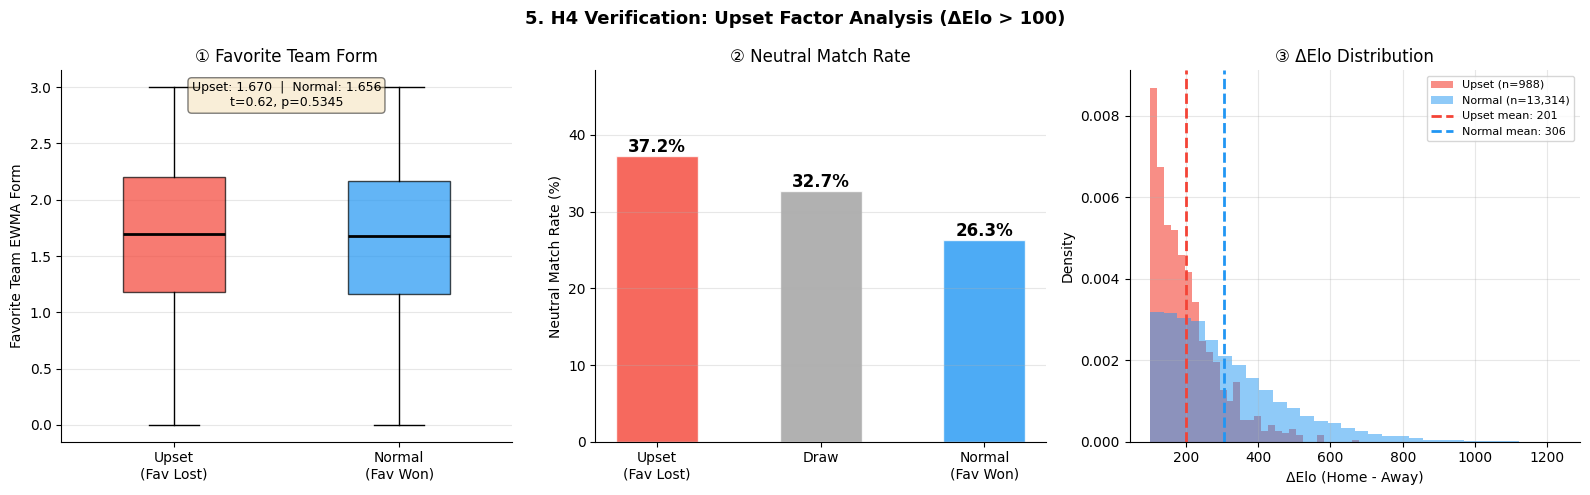


=== 강팀 폼 비교 ===
  이변 시 강팀 평균 폼:  1.6702
  정상 시 강팀 평균 폼:  1.6565
  차이:                  0.0138
  t-test p-value:        0.5345 (비유의)

=== 중립경기 비율 ===
  이변 시 중립경기 비율: 37.2%
  정상 시 중립경기 비율: 26.3%

=== ΔElo 평균 비교 ===
  이변 경기 평균 ΔElo:   201.2
  정상 경기 평균 ΔElo:   306.1


In [5]:
# ============================================================
# EDA 5. H4 검증: 이변(Upset) 요인 분석
# ============================================================
# 목적: "이변 발생 시 강팀의 단기 폼 저하와 중립경기 여부가
#        주요 원인"이라는 가설(H4) 시각적 검증
#
# 이변(Upset) 정의:
#   delta_elo > 100 (홈팀이 Elo 100점 이상 우세)인데
#   Away Win(원정팀 승리=0)이 나온 경우
#   → 명백한 전력 열세 팀이 이긴 경우만 이변으로 정의
#
# 비교 그룹:
#   upset     = 강팀(홈)이 졌을 때
#   non_upset = 강팀(홈)이 이겼을 때
#
# 확인 항목:
#   1) 강팀의 EWMA 폼 차이 (이변 vs 정상)
#   2) 중립경기 비율 차이
#   3) ΔElo 분포 차이 (얼마나 유리했는데 졌나)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

SAVE_PATH = "/content/drive/MyDrive/[미래융합교육원] 1팀 공유사항/1차 머신러닝 프로젝트/@프로젝트 자료/03. 프로젝트 자료/data/preprocessed"

X_train = pd.read_csv(f"{SAVE_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{SAVE_PATH}/X_test.csv")
y_train = pd.read_csv(f"{SAVE_PATH}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{SAVE_PATH}/y_test.csv").squeeze()

X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)

df = X_all.copy()
df["label"] = y_all.values

# 이변 정의: delta_elo > 100 인데 Away Win
THRESHOLD = 100
favored   = df[df["delta_elo"] > THRESHOLD]          # 강팀(홈)이 유리한 경기
upset     = favored[favored["label"] == 0]            # 약팀이 이긴 경기 (이변)
non_upset = favored[favored["label"] == 2]            # 강팀이 이긴 경기 (정상)
draw_case = favored[favored["label"] == 1]            # 무승부

print(f"ΔElo > {THRESHOLD} 전체: {len(favored):,}경기")
print(f"  정상(강팀 승): {len(non_upset):,}경기 ({len(non_upset)/len(favored)*100:.1f}%)")
print(f"  이변(약팀 승): {len(upset):,}경기    ({len(upset)/len(favored)*100:.1f}%)")
print(f"  무승부:        {len(draw_case):,}경기  ({len(draw_case)/len(favored)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("5. H4 Verification: Upset Factor Analysis (ΔElo > 100)",
             fontsize=13, fontweight="bold")

# --- 왼쪽: 강팀 EWMA 폼 비교 ---
ax = axes[0]
data_form = [
    upset["home_form"].dropna().values,
    non_upset["home_form"].dropna().values,
]
bp = ax.boxplot(data_form, labels=["Upset\n(Fav Lost)", "Normal\n(Fav Won)"],
                patch_artist=True, widths=0.45,
                medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#F44336"); bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("#2196F3"); bp["boxes"][1].set_alpha(0.7)

# t-test로 통계적 유의성 확인
t_stat, p_val = stats.ttest_ind(
    upset["home_form"].dropna(),
    non_upset["home_form"].dropna()
)
mu_up = upset["home_form"].mean()
mu_no = non_upset["home_form"].mean()

ax.set_ylabel("Favorite Team EWMA Form")
ax.set_title("① Favorite Team Form")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
ax.text(0.5, 0.97,
        f"Upset: {mu_up:.3f}  |  Normal: {mu_no:.3f}\nt={t_stat:.2f}, p={p_val:.4f}",
        transform=ax.transAxes, va="top", ha="center", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# --- 가운데: 중립경기 비율 ---
ax2 = axes[1]
neutral_upset  = upset["neutral"].mean() * 100
neutral_normal = non_upset["neutral"].mean() * 100
neutral_draw   = draw_case["neutral"].mean() * 100

bars = ax2.bar(
    ["Upset\n(Fav Lost)", "Draw", "Normal\n(Fav Won)"],
    [neutral_upset, neutral_draw, neutral_normal],
    color=["#F44336","#9E9E9E","#2196F3"],
    alpha=0.8, edgecolor="white", width=0.5
)
for bar, v in zip(bars, [neutral_upset, neutral_draw, neutral_normal]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")

ax2.set_ylabel("Neutral Match Rate (%)")
ax2.set_title("② Neutral Match Rate")
ax2.set_ylim(0, max(neutral_upset, neutral_normal, neutral_draw) * 1.3)
ax2.grid(axis="y", alpha=0.3)
ax2.spines[["top","right"]].set_visible(False)

# --- 오른쪽: ΔElo 분포 비교 ---
ax3 = axes[2]
ax3.hist(upset["delta_elo"],     bins=30, alpha=0.6,
         color="#F44336", label=f"Upset (n={len(upset):,})",     edgecolor="none", density=True)
ax3.hist(non_upset["delta_elo"], bins=30, alpha=0.5,
         color="#2196F3", label=f"Normal (n={len(non_upset):,})", edgecolor="none", density=True)

ax3.axvline(upset["delta_elo"].mean(),     color="#F44336", linestyle="--",
            linewidth=2, label=f"Upset mean: {upset['delta_elo'].mean():.0f}")
ax3.axvline(non_upset["delta_elo"].mean(), color="#2196F3", linestyle="--",
            linewidth=2, label=f"Normal mean: {non_upset['delta_elo'].mean():.0f}")

ax3.set_xlabel("ΔElo (Home - Away)")
ax3.set_ylabel("Density")
ax3.set_title("③ ΔElo Distribution")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)
ax3.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 추가 수치
print(f"\n=== 강팀 폼 비교 ===")
print(f"  이변 시 강팀 평균 폼:  {mu_up:.4f}")
print(f"  정상 시 강팀 평균 폼:  {mu_no:.4f}")
print(f"  차이:                  {mu_up - mu_no:.4f}")
print(f"  t-test p-value:        {p_val:.4f} {'(유의)' if p_val < 0.05 else '(비유의)'}")
print(f"\n=== 중립경기 비율 ===")
print(f"  이변 시 중립경기 비율: {neutral_upset:.1f}%")
print(f"  정상 시 중립경기 비율: {neutral_normal:.1f}%")
print(f"\n=== ΔElo 평균 비교 ===")
print(f"  이변 경기 평균 ΔElo:   {upset['delta_elo'].mean():.1f}")
print(f"  정상 경기 평균 ΔElo:   {non_upset['delta_elo'].mean():.1f}")

## EDA 5. H4 검증: 이변 요인 분석

**결론: H4 부분 지지 — 폼은 유의하지 않고, 중립경기는 유의함**

| 항목 | 이변 시 | 정상 시 |
|---|---|---|
| 강팀 EWMA 폼 | 1.670 | 1.656 |
| 중립경기 비율 | **37.2%** | 26.3% |
| 평균 ΔElo | 201.2 | **306.1** |
| 이변율 | 5.8% | - |

### ① 강팀 폼 저하 → 비유의 (H4 부분 기각)
이변 시 폼(1.670) vs 정상 시 폼(1.656), 차이 0.014
t-test p-value = 0.5345 → 통계적으로 유의하지 않음
→ EWMA 폼만으로는 이변을 설명하기 어려움

### ② 중립경기 비율 → 유의 (H4 부분 지지)
이변 시 중립경기 37.2% vs 정상 시 26.3%, 약 11%p 차이
→ 중립경기에서 홈 어드밴티지가 사라지면 이변 가능성 상승
→ neutral 피처가 이변 예측에 실질적으로 기여할 것으로 예상

### ③ ΔElo 차이 → 이변은 상대적으로 덜 유리한 경기에서 발생
이변 경기 평균 ΔElo 201 vs 정상 경기 306
→ ΔElo가 압도적으로 크면(300+) 이변 가능성 거의 없음
→ ΔElo 100~200 구간이 이변 다발 구간

### → 모델링 시사점
- H4 중 "폼 저하" 요인은 EDA 수준에서 확인 안 됨
  → SHAP 단계에서 재검증 필요
- "중립경기" 요인은 확인됨 → neutral 피처 중요도 주목
- 이변율 5.8%는 낮지만, WC에서는 더 높을 수 있음
  → 이변 subset SHAP 분석 시 WC 경기만 따로 볼 것

WC 경기 수: 967경기
  Win: 406  Draw: 200  Loss: 361


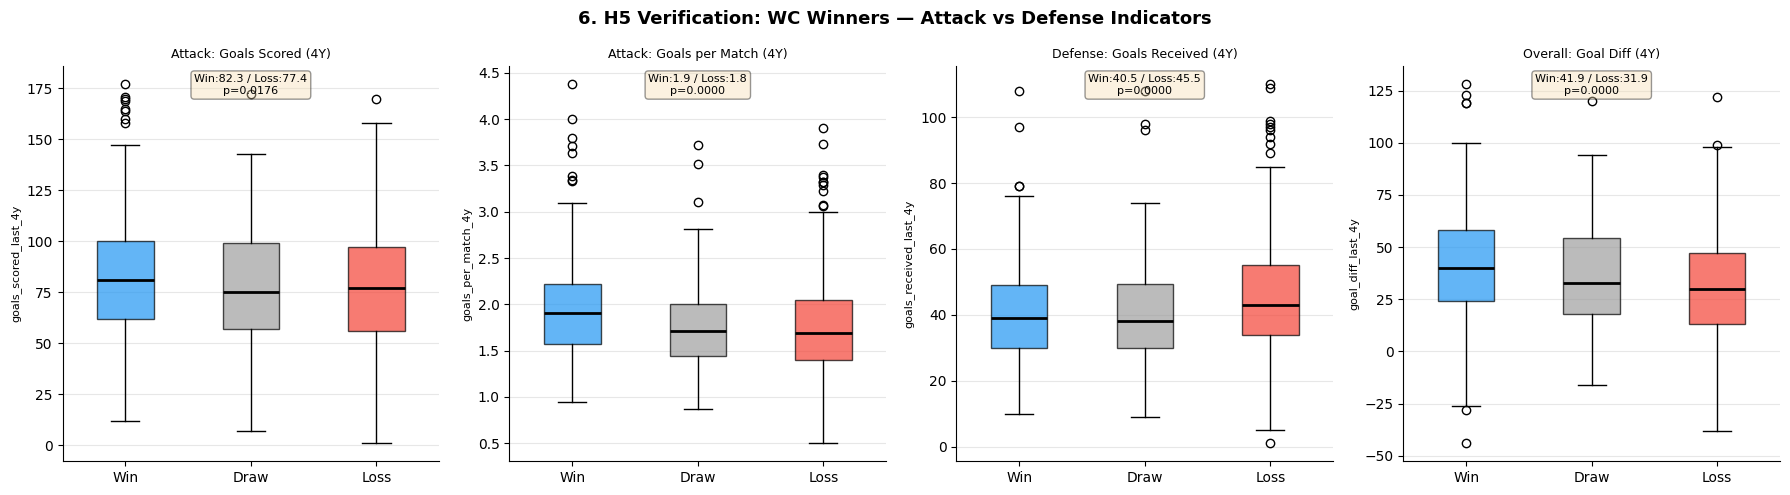


=== WC 승리팀 vs 패배팀 지표 비교 (홈팀 기준) ===
  Attack: Goals Scored (4Y)
    Win: 82.33  |  Loss: 77.36  |  diff: +4.97  |  p=0.0176
  Attack: Goals per Match (4Y)
    Win: 1.94  |  Loss: 1.76  |  diff: +0.18  |  p=0.0000
  Defense: Goals Received (4Y)
    Win: 40.47  |  Loss: 45.47  |  diff: -5.00  |  p=0.0000
  Overall: Goal Diff (4Y)
    Win: 41.86  |  Loss: 31.89  |  diff: +9.97  |  p=0.0000


In [6]:
# ============================================================
# EDA 6. H5 검증: 역대 WC 우승팀 공격 vs 수비 지표
# ============================================================
# 목적: "역대 우승팀은 공격 지표보다 수비 안정성 지표가
#        더 강한 공통 신호"라는 가설(H5) 시각적 검증
#
# 분석 방법:
#   WC 경기(is_wc=1)만 필터링
#   홈팀 기준으로 승/무/패 그룹 분류
#   공격 지표(goals_scored, goals_per_match)와
#   수비 지표(goals_received)의 분포 비교
#   → 승리 그룹에서 수비 지표 차이가 공격 지표보다 더 두드러지면 H5 지지
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

SAVE_PATH = "/content/drive/MyDrive/[미래융합교육원] 1팀 공유사항/1차 머신러닝 프로젝트/@프로젝트 자료/03. 프로젝트 자료/data/preprocessed"

X_train = pd.read_csv(f"{SAVE_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{SAVE_PATH}/X_test.csv")
y_train = pd.read_csv(f"{SAVE_PATH}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{SAVE_PATH}/y_test.csv").squeeze()

X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)

df = X_all.copy()
df["label"] = y_all.values

# WC 경기만 필터
wc = df[df["is_wc"] == 1].copy()
wc["result"] = wc["label"].map({2: "Win", 1: "Draw", 0: "Loss"})

print(f"WC 경기 수: {len(wc):,}경기")
print(f"  Win: {(wc['label']==2).sum()}  Draw: {(wc['label']==1).sum()}  Loss: {(wc['label']==0).sum()}")

# 분석할 피처 쌍 (공격 vs 수비)
features = [
    ("home_goals_scored_last_4y",   "Attack: Goals Scored (4Y)",    "#FF9800"),
    ("home_goals_per_match_4y",     "Attack: Goals per Match (4Y)", "#FF9800"),
    ("home_goals_received_last_4y", "Defense: Goals Received (4Y)", "#4CAF50"),
    ("home_goal_diff_last_4y",      "Overall: Goal Diff (4Y)",      "#9C27B0"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("6. H5 Verification: WC Winners — Attack vs Defense Indicators",
             fontsize=13, fontweight="bold")

order  = ["Win", "Draw", "Loss"]
colors = ["#2196F3", "#9E9E9E", "#F44336"]

for ax, (feat, title, color) in zip(axes, features):
    if feat not in wc.columns:
        ax.set_visible(False)
        continue

    data = [wc[wc["result"] == r][feat].dropna().values for r in order]

    bp = ax.boxplot(data, labels=order, patch_artist=True,
                    widths=0.45, medianprops=dict(color="black", linewidth=2))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)

    # Win vs Loss t-test
    t, p = stats.ttest_ind(data[0], data[2])
    means = [np.mean(d) for d in data]

    ax.set_title(title, fontsize=9)
    ax.set_ylabel(feat.replace("home_",""), fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    ax.text(0.5, 0.98,
            f"Win:{means[0]:.1f} / Loss:{means[2]:.1f}\np={p:.4f}",
            transform=ax.transAxes, va="top", ha="center", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.4))

plt.tight_layout()
plt.show()

# 수치 요약
print("\n=== WC 승리팀 vs 패배팀 지표 비교 (홈팀 기준) ===")
for feat, title, _ in features:
    if feat not in wc.columns:
        continue
    win_mean  = wc[wc["result"]=="Win"][feat].mean()
    loss_mean = wc[wc["result"]=="Loss"][feat].mean()
    t, p      = stats.ttest_ind(
        wc[wc["result"]=="Win"][feat].dropna(),
        wc[wc["result"]=="Loss"][feat].dropna()
    )
    print(f"  {title}")
    print(f"    Win: {win_mean:.2f}  |  Loss: {loss_mean:.2f}  |  diff: {win_mean-loss_mean:+.2f}  |  p={p:.4f}")

## EDA 6. H5 검증: WC 승리팀 공격 vs 수비 지표

**결론: H5 지지 — 수비 지표가 공격 지표보다 더 강한 신호**

| 지표 | Win | Loss | 차이 | p-value | 유의성 |
|---|---|---|---|---|---|
| Goals Scored (4Y) | 82.3 | 77.4 | +4.97 | 0.0176 | ✅ 유의 |
| Goals per Match (4Y) | 1.94 | 1.76 | +0.18 | 0.0000 | ✅ 유의 |
| **Goals Received (4Y)** | **40.5** | **45.5** | **-5.00** | **0.0000** | ✅ 유의 |
| Goal Diff (4Y) | 41.9 | 31.9 | +9.97 | 0.0000 | ✅ 유의 |

### ① 수비 지표가 더 강한 신호
Goals Received p=0.0000 (공격 Goals Scored p=0.0176보다 훨씬 강함)
승리팀 실점 40.5 vs 패배팀 45.5 → 5골 차이
→ **H5("수비 안정성이 더 강한 공통 신호") 지지**

### ② 공격도 유의하나 신호 강도가 약함
Goals Scored 차이 +4.97, p=0.0176
Goals per Match 차이 +0.18, p=0.0000
→ 공격도 중요하지만 수비만큼 결정적이지 않음

### ③ Goal Diff가 가장 종합적인 지표
Win 41.9 vs Loss 31.9, 차이 +10.0, p=0.0000
→ goal_diff_last_4y가 단일 피처로 강력한 예측 변수임을 시사

### → 모델링 시사점
- home_goals_received_last_4y, gap_goal_diff를 중요 피처로 주목
- 2026 WC 한국 분석 시:
  한국 수비 지표(goals_received)가 상대 대비 낮을수록 승리 가능성 높음
- SHAP 분석에서 수비 관련 피처 중요도 확인 예정

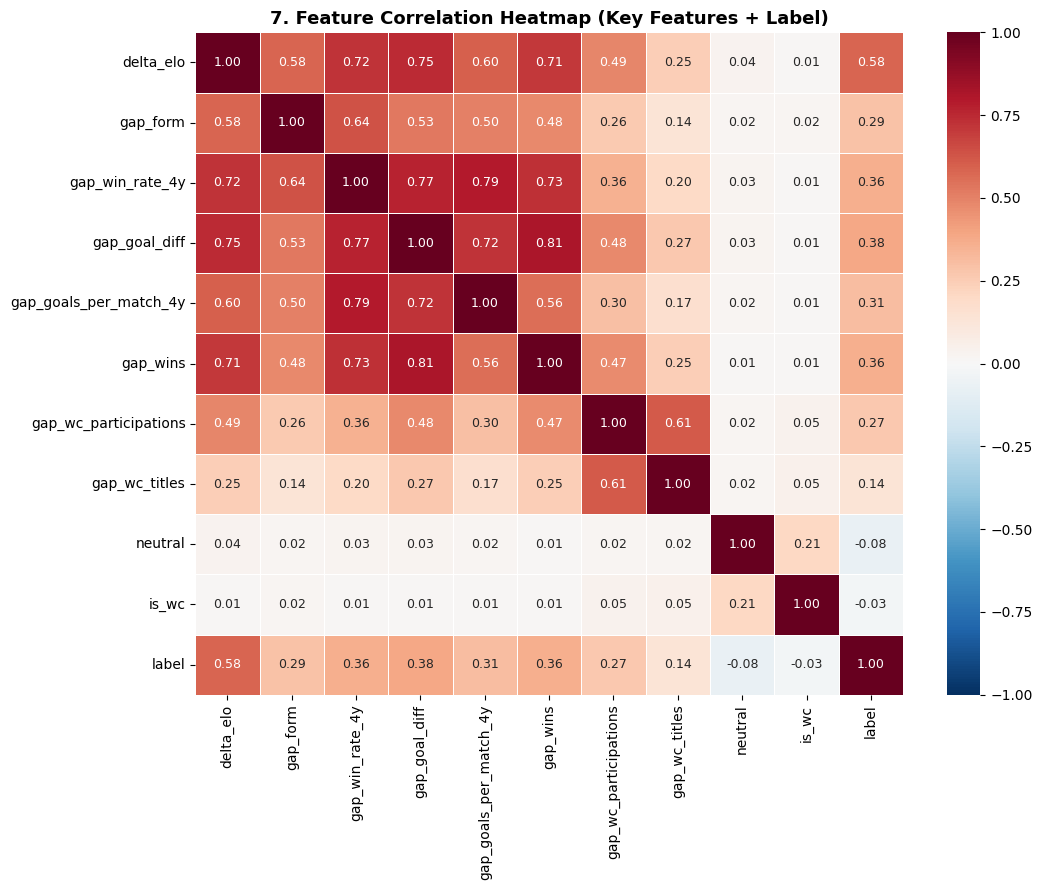

=== label과의 상관계수 순위 ===
  delta_elo                     : +0.5809
  gap_goal_diff                 : +0.3838
  gap_wins                      : +0.3648
  gap_win_rate_4y               : +0.3632
  gap_goals_per_match_4y        : +0.3095
  gap_form                      : +0.2915
  gap_wc_participations         : +0.2723
  gap_wc_titles                 : +0.1388
  is_wc                         : -0.0275
  neutral                       : -0.0760


In [7]:
# ============================================================
# EDA 7. 피처 상관관계 히트맵
# ============================================================
# 목적: 핵심 피처들 간 다중공선성 및 label과의 상관관계 확인
#       → 서로 상관이 높은 피처끼리는 모델에서 중복 정보 가능성
#       → label과 상관 높은 피처 = 예측력 높은 피처 후보
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SAVE_PATH = "/content/drive/MyDrive/[미래융합교육원] 1팀 공유사항/1차 머신러닝 프로젝트/@프로젝트 자료/03. 프로젝트 자료/data/preprocessed"

X_train = pd.read_csv(f"{SAVE_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{SAVE_PATH}/X_test.csv")
y_train = pd.read_csv(f"{SAVE_PATH}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{SAVE_PATH}/y_test.csv").squeeze()

X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)

# 핵심 피처만 선택 (gap 피처 + 환경 피처)
KEY_FEATURES = [
    "delta_elo",
    "gap_form",
    "gap_win_rate_4y",
    "gap_goal_diff",
    "gap_goals_per_match_4y",
    "gap_wins",
    "gap_wc_participations",
    "gap_wc_titles",
    "neutral",
    "is_wc",
]
key_feats = [f for f in KEY_FEATURES if f in X_all.columns]

df_corr          = X_all[key_feats].copy()
df_corr["label"] = y_all.values
corr_matrix      = df_corr.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={"size": 9}
)
ax.set_title("7. Feature Correlation Heatmap (Key Features + Label)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# label과의 상관계수 순위
print("=== label과의 상관계수 순위 ===")
label_corr = corr_matrix["label"].drop("label").sort_values(ascending=False)
for feat, corr in label_corr.items():
    print(f"  {feat:30s}: {corr:+.4f}")

## EDA 7. 피처 상관관계 히트맵

**결론: delta_elo 압도적 1위, 4년 성적 피처들 간 다중공선성 주의**

### ① label과의 상관계수 순위
| 순위 | 피처 | 상관계수 |
|---|---|---|
| 1 | delta_elo | **+0.581** |
| 2 | gap_goal_diff | +0.384 |
| 3 | gap_wins | +0.365 |
| 4 | gap_win_rate_4y | +0.363 |
| 5 | gap_goals_per_match_4y | +0.310 |
| 6 | gap_form | +0.292 |
| 7 | gap_wc_participations | +0.272 |
| 8 | gap_wc_titles | +0.139 |
| 9 | is_wc | -0.028 |
| 10 | neutral | -0.076 |

### ② 4년 성적 피처 간 다중공선성 경고
gap_goal_diff ↔ gap_wins: **0.81**
gap_win_rate_4y ↔ gap_goal_diff: **0.77**
gap_win_rate_4y ↔ gap_wins: **0.73**
→ 4년 성적 기반 피처들이 서로 강하게 연관됨
→ 선형 모델(Logistic Regression)에서 불안정할 수 있음
→ 트리 모델(XGBoost/LightGBM)은 다중공선성에 강해 영향 적음

### ③ delta_elo와 4년 성적 피처도 높은 상관
delta_elo ↔ gap_win_rate_4y: **0.72**
delta_elo ↔ gap_goal_diff: **0.75**
→ Elo 자체가 4년 성적을 상당 부분 반영하고 있음
→ 그럼에도 delta_elo의 label 상관(0.581)이 가장 높아
  Elo가 단순 4년 성적보다 더 정제된 전력 지표임을 확인

### ④ neutral, is_wc는 label과 거의 무상관
neutral: -0.076, is_wc: -0.028
→ 단독 예측력은 낮지만 다른 피처와 결합 시 이변·WC 패턴 포착에 기여
→ 인터랙션 피처로서 트리 모델에서 활용 가능

### → 모델링 시사점
- Logistic Regression: Ridge 정규화 필수 (다중공선성 대응)
- XGBoost/LightGBM: 다중공선성 영향 적으나
  피처 중요도 해석 시 유사 피처 간 중요도 분산 주의
- SHAP에서 gap_goal_diff vs gap_wins vs gap_win_rate_4y
  중 실질 기여 피처 확인 필요

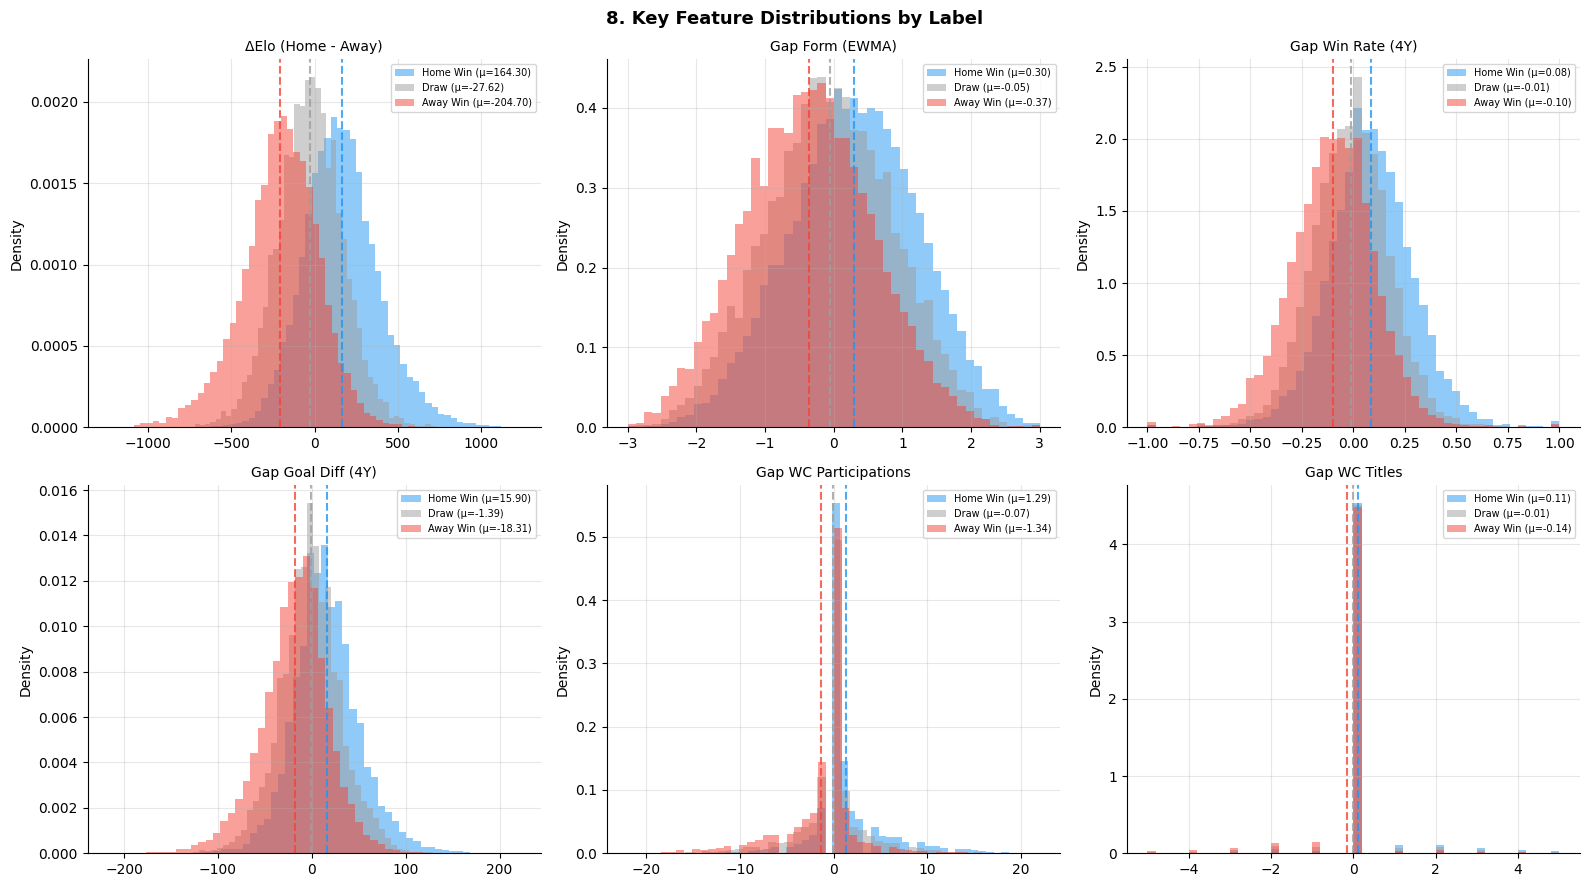

=== 레이블별 주요 피처 평균값 ===

  ΔElo (Home - Away)
    Home Win    : +164.3006
    Draw        : -27.6238
    Away Win    : -204.7012

  Gap Form (EWMA)
    Home Win    : +0.2967
    Draw        : -0.0539
    Away Win    : -0.3660

  Gap Win Rate (4Y)
    Home Win    : +0.0848
    Draw        : -0.0110
    Away Win    : -0.1006

  Gap Goal Diff (4Y)
    Home Win    : +15.9048
    Draw        : -1.3927
    Away Win    : -18.3132

  Gap WC Participations
    Home Win    : +1.2855
    Draw        : -0.0732
    Away Win    : -1.3394

  Gap WC Titles
    Home Win    : +0.1147
    Draw        : -0.0068
    Away Win    : -0.1422


In [8]:
# ============================================================
# EDA 8. 주요 피처 분포 (레이블별)
# ============================================================
# 목적: 핵심 피처들이 레이블(H/D/A)에 따라 분포가 얼마나
#       다른지 시각적으로 확인
#       → 분포 차이가 클수록 해당 피처의 판별력이 높음
#       → 모델이 어떤 피처를 기준으로 분류할지 직관적 이해
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SAVE_PATH = "/content/drive/MyDrive/[미래융합교육원] 1팀 공유사항/1차 머신러닝 프로젝트/@프로젝트 자료/03. 프로젝트 자료/data/preprocessed"

X_train = pd.read_csv(f"{SAVE_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{SAVE_PATH}/X_test.csv")
y_train = pd.read_csv(f"{SAVE_PATH}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{SAVE_PATH}/y_test.csv").squeeze()

X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)

LABEL_MAP   = {2: "Home Win", 1: "Draw", 0: "Away Win"}
COLOR_MAP   = {2: "#2196F3", 1: "#9E9E9E", 0: "#F44336"}
LABEL_ORDER = [2, 1, 0]

df = X_all.copy()
df["label"] = y_all.values

# 시각화할 피처 목록
plot_features = [
    ("delta_elo",              "ΔElo (Home - Away)"),
    ("gap_form",               "Gap Form (EWMA)"),
    ("gap_win_rate_4y",        "Gap Win Rate (4Y)"),
    ("gap_goal_diff",          "Gap Goal Diff (4Y)"),
    ("gap_wc_participations",  "Gap WC Participations"),
    ("gap_wc_titles",          "Gap WC Titles"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("8. Key Feature Distributions by Label",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for ax, (feat, title) in zip(axes, plot_features):
    if feat not in df.columns:
        ax.set_visible(False)
        continue
    for lbl in LABEL_ORDER:
        vals = df[df["label"] == lbl][feat].dropna()
        ax.hist(vals, bins=50, alpha=0.5,
                label=f"{LABEL_MAP[lbl]} (μ={vals.mean():.2f})",
                color=COLOR_MAP[lbl], edgecolor="none", density=True)
        # 평균선 표시
        ax.axvline(vals.mean(), color=COLOR_MAP[lbl],
                   linestyle="--", linewidth=1.5, alpha=0.8)

    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 레이블별 평균값 출력
print("=== 레이블별 주요 피처 평균값 ===")
for feat, title in plot_features:
    if feat not in df.columns:
        continue
    print(f"\n  {title}")
    for lbl in LABEL_ORDER:
        mu = df[df["label"]==lbl][feat].mean()
        print(f"    {LABEL_MAP[lbl]:12s}: {mu:+.4f}")

## EDA 8. 주요 피처 분포 (레이블별)

**결론: 모든 피처에서 Home Win > Draw > Away Win 순서로 일관된 분리**

| 피처 | Home Win μ | Draw μ | Away Win μ | 분리도 |
|---|---|---|---|---|
| ΔElo | +164.3 | -27.6 | -204.7 | ★★★★★ |
| Gap Goal Diff | +15.9 | -1.4 | -18.3 | ★★★★ |
| Gap Form | +0.30 | -0.05 | -0.37 | ★★★ |
| Gap Win Rate | +0.08 | -0.01 | -0.10 | ★★★ |
| Gap WC Participations | +1.29 | -0.07 | -1.34 | ★★ |
| Gap WC Titles | +0.11 | -0.01 | -0.14 | ★ |

### ① ΔElo 분리도 압도적
Home Win 평균 +164 vs Away Win 평균 -205, 약 370점 차이
세 분포가 가장 뚜렷하게 분리됨 → H1 재확인

### ② Draw는 항상 중간값 (0 근방)
모든 피처에서 Draw 평균이 0에 가장 가까움
→ 무승부는 두 팀이 비슷할 때 발생한다는 구조적 특성 재확인
→ 분포가 겹치는 구간이 넓어 모델이 Draw를 구분하기 어려운 이유

### ③ Gap WC Titles 분리도 낮음
Home Win +0.11 vs Away Win -0.14, 차이 0.25로 가장 작음
대부분 경기에서 0에 몰려있는 spike 형태
→ 우승 경험이 있는 팀 간 경기가 드물기 때문
→ 단독 예측력은 낮으나 WC 경기에서 선별적으로 중요할 수 있음

### → 모델링 시사점
- delta_elo, gap_goal_diff가 분포 분리도 가장 높음
  → 베이스라인 모델에서 이 두 피처만으로도 상당한 성능 기대
- Draw 예측이 어려운 이유가 분포에서 명확히 확인됨
  → 세 분포가 중앙에서 심하게 겹침

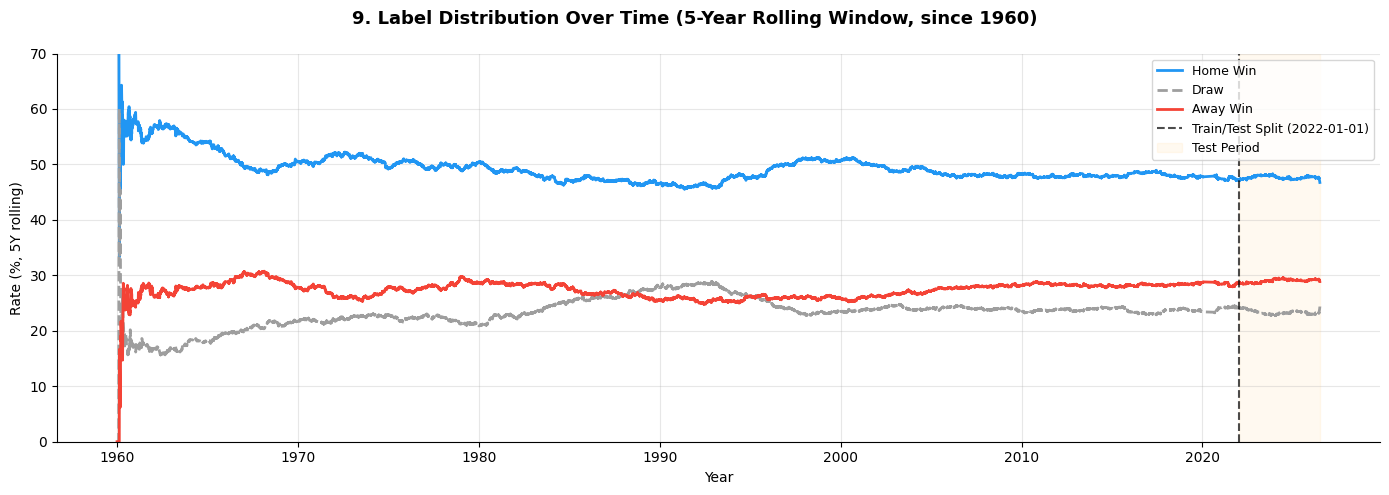

=== 10년 단위 평균 비율 ===
  1960s: 홈승 51.9%  무 20.4%  원정승 27.8%  (n=2,446)
  1970s: 홈승 49.9%  무 21.9%  원정승 28.2%  (n=3,661)
  1980s: 홈승 46.8%  무 26.7%  원정승 26.5%  (n=4,632)
  1990s: 홈승 49.4%  무 24.6%  원정승 26.0%  (n=6,693)
  2000s: 홈승 48.6%  무 23.8%  원정승 27.7%  (n=9,169)
  2010s: 홈승 47.9%  무 23.8%  원정승 28.4%  (n=9,210)
  2020s: 홈승 47.0%  무 24.3%  원정승 28.7%  (n=5,951)


In [9]:
# ============================================================
# EDA 9. 시간에 따른 레이블 분포 변화
# ============================================================
# 목적: 홈 어드밴티지가 시간이 지남에 따라 감소하는지 확인
#       → 최근 데이터일수록 원정승 비율 증가 추세면
#         시간 기반 train/test split의 타당성을 추가 지지
#       → 모델이 최근 트렌드를 반영하는지 확인하는 기초 분석
#
# 방법: 5년 롤링 윈도우로 연도별 승/무/패 비율 계산
#       train/test split 기준선(2022-01-01) 표시
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SAVE_PATH = "/content/drive/MyDrive/[미래융합교육원] 1팀 공유사항/1차 머신러닝 프로젝트/@프로젝트 자료/03. 프로젝트 자료/data/preprocessed"

results = pd.read_csv(
    f"{SAVE_PATH}/results_preprocessed.csv",
    parse_dates=["date"]
)

COLOR_MAP = {2: "#2196F3", 1: "#9E9E9E", 0: "#F44336"}

# label 재생성 (home_score, away_score 기반)
results["label"] = np.where(
    results["home_score"] > results["away_score"], 2,
    np.where(results["home_score"] < results["away_score"], 0, 1)
)

df_time = results.set_index("date").sort_index()

# 1960년 이후만 (그 이전은 경기 수가 너무 적어 롤링 불안정)
df_time = df_time[df_time.index >= "1960-01-01"]

# 5년(1825일) 롤링 비율
roll_home = (df_time["label"] == 2).rolling("1825D").mean() * 100
roll_draw = (df_time["label"] == 1).rolling("1825D").mean() * 100
roll_away = (df_time["label"] == 0).rolling("1825D").mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("9. Label Distribution Over Time (5-Year Rolling Window, since 1960)",
             fontsize=13, fontweight="bold")

ax.plot(roll_home.index, roll_home, color=COLOR_MAP[2],
        label="Home Win", linewidth=2)
ax.plot(roll_draw.index, roll_draw, color=COLOR_MAP[1],
        label="Draw",     linewidth=2, linestyle="--")
ax.plot(roll_away.index, roll_away, color=COLOR_MAP[0],
        label="Away Win", linewidth=2)

# Train/Test split 기준선
ax.axvline(pd.Timestamp("2022-01-01"), color="black",
           linestyle="--", linewidth=1.5, alpha=0.7, label="Train/Test Split (2022-01-01)")

# 구간 음영
ax.axvspan(pd.Timestamp("2022-01-01"), df_time.index.max(),
           alpha=0.06, color="orange", label="Test Period")

ax.set_xlabel("Year")
ax.set_ylabel("Rate (%, 5Y rolling)")
ax.set_ylim(0, 70)
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 연도별 10년 단위 요약
print("=== 10년 단위 평균 비율 ===")
results_1960 = results[results["date"] >= "1960-01-01"].copy()
results_1960["decade"] = (results_1960["date"].dt.year // 10) * 10
for decade, grp in results_1960.groupby("decade"):
    hw = (grp["label"] == 2).mean() * 100
    d  = (grp["label"] == 1).mean() * 100
    aw = (grp["label"] == 0).mean() * 100
    print(f"  {decade}s: 홈승 {hw:.1f}%  무 {d:.1f}%  원정승 {aw:.1f}%  (n={len(grp):,})")

## EDA 9. 시간에 따른 레이블 분포 변화

**결론: 홈 어드밴티지 완만한 감소 추세, 분포는 전반적으로 안정적**

| 연대 | 홈승 | 무승부 | 원정승 | n |
|---|---|---|---|---|
| 1960s | 51.9% | 20.4% | 27.8% | 2,446 |
| 1980s | 46.8% | 26.7% | 26.5% | 4,632 |
| 2000s | 48.6% | 23.8% | 27.7% | 9,169 |
| 2010s | 47.9% | 23.8% | 28.4% | 9,210 |
| **2020s** | **47.0%** | **24.3%** | **28.7%** | 5,951 |

### ① 홈 어드밴티지 완만한 감소
1960s 홈승 51.9% → 2020s 47.0%, 약 5%p 감소
롤링 곡선에서 완만한 우하향 추세 확인
→ 교통·원정 환경 개선, 국제 경기 증가로 홈 어드밴티지 희석

### ② 원정승 완만한 증가
1960s 27.8% → 2020s 28.7%, 약 1%p 증가
→ 전술 발전과 원정 적응력 향상이 원인으로 추정

### ③ 전체 분포는 안정적 — 시간 기반 split 타당성 확인
60년간 세 레이블 비율이 크게 변하지 않음
→ 2022-01-01 기준 Train/Test split 시
  Test 기간(2022~)이 Train과 분포상 크게 다르지 않음
→ 시간 기반 split이 타당함을 추가 확인

### ④ 1960년대 초 불안정 구간
롤링 초기(1960~1963) 급등락은 롤링 워밍업 효과
데이터가 충분히 쌓이는 1965년 이후부터 안정

### → 모델링 시사점
- 시간에 따른 분포 변화가 크지 않아
  과거 데이터로 학습해도 최근 경기 예측에 무리 없음
- 단, 2020s 원정승 소폭 증가 추세는
  Test set에서 Away Win 예측을 약간 더 중요하게 볼 필요

## EDA 전체 요약

| # | 분석 | 핵심 결론 |
|---|---|---|
| 1 | 레이블 분포 | 홈승 49% / 무 23% / 원정승 28% — 무승부 클래스 불균형 주의 |
| 2 | 대회 유형별 | WC일수록 원정승↑, 홈 어드밴티지 희석 — sample_weight 적용 필수 |
| 3 | H1 검증 | **ΔElo 강력 지지** — 단조증가 확인, 상관계수 0.581로 압도적 1위 |
| 4 | H2 검증 | **H2 기각** — 4년 승률(0.363) > EWMA 폼(0.292), 폼은 보조 피처 |
| 5 | H4 검증 | **부분 지지** — 중립경기 비율 유의(37% vs 26%), 폼 저하는 비유의 |
| 6 | H5 검증 | **H5 지지** — 수비 지표(p=0.000)가 공격 지표(p=0.018)보다 강한 신호 |
| 7 | 상관관계 | ΔElo 압도적 1위 — 4년 성적 피처 간 다중공선성(0.7~0.8) 주의 |
| 8 | 피처 분포 | Draw는 모든 피처에서 중간값(≈0) — 세 분포 겹침으로 분리 구조적 어려움 |
| 9 | 시간 추세 | 60년간 분포 안정적 — 시간 기반 Train/Test split 타당성 확인 |

### 모델링으로 가져갈 핵심 시사점
1. `delta_elo`를 중심으로 한 베이스라인 모델이 의미 있는 성능 낼 것으로 예상
2. 무승부 예측을 위한 클래스 가중치 보정 필요
3. Logistic Regression에는 Ridge 정규화 필수 (다중공선성 대응)
4. `neutral`, `is_wc` 피처는 단독 예측력은 낮으나 이변·WC 패턴 포착에 기여
5. SHAP 단계에서 H2(폼), H4(폼 저하) 재검증 예정